# TFM Deteccion - Ejecucion final

Pipeline definitivo: solo CNNDetection, 3 modelos (ResNet-50, ViT-B/16, UFD; FreqNet en stand-by), trainset de ejecucion 100.000 imgs (5000 por categoria, balance 50/50 real/fake) sobre las 20 categorias de progan_train. Validacion (progan_val) y test (progan_test + CNN_synth_testset, E1+E1b) completos.

El trainset se construye via API de Drive con streaming + range requests (NO via el mount FUSE) para evitar que Colab descargue el zip entero como cache local. Ver `problema_carga_datasets.md` para detalles.

Requisitos:
- Runtime Colab con GPU (T4 o superior).
- En `MyDrive/cnndetection-datasets/` (o como acceso directo): `progan_train.zip`, `progan_val.zip`, `progan_testset.zip`, `CNN_synth_testset.zip`.
- (Opcional) cuenta de wandb.


## 1. Drive + repo + dependencias

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!rm -rf /content/tfm_deteccion
!git clone https://github.com/manuelpalasanchez/tfm_deteccion.git
%cd /content/tfm_deteccion
!git pull

Mounted at /content/drive
Cloning into 'tfm_deteccion'...
remote: Enumerating objects: 197, done.
remote: Counting objects: 100% (197/197), done.
remote: Compressing objects: 100% (131/131), done.
remote: Total 197 (delta 101), reused 157 (delta 61), pack-reused 0 (from 0)
Receiving objects: 100% (197/197), 161.16 KiB | 20.14 MiB/s, done.
Resolving deltas: 100% (101/101), done.
/content/tfm_deteccion
Already up to date.


In [ ]:
!pip install -q -r requirements.txt

## 2. Inventario del progan_train.zip (opcional)

Lee el indice del zip directamente desde Drive (sin descomprimir nada). Ya hecho una vez: 20 cats x 36k imgs (50/50). Ejecutar solo si quieres reverificar.

In [ ]:
ZIP_TRAIN = '/content/drive/MyDrive/cnndetection-datasets/progan_train.zip'
!python scripts/scan_cnndetection.py --zip {ZIP_TRAIN} --csv reports/scan_progan_train.csv


=== progan_train ===
categoria                real     fake      total       tamano
--------------------------------------------------------------
airplane                18003    18003      36006      2.75 GB
bicycle                 18003    18003      36006      3.92 GB
bird                    18003    18003      36006      3.47 GB
boat                    18002    18003      36005      3.51 GB
bottle                  18003    18003      36006      2.72 GB
bus                     18003    18003      36006      3.58 GB
car                     18003    18003      36006      3.47 GB
cat                     18003    18003      36006      3.46 GB
chair                   18003    18003      36006      2.95 GB
cow                     18003    18003      36006      4.00 GB
diningtable             18003    18003      36006      3.62 GB
dog                     18003    18003      36006      3.68 GB
horse                   18003    18003      36006      3.91 GB
motorbike               18003    

## 3. Construccion del trainset de ejecucion (via Drive API)

Para evitar el problema de la cache FUSE de Drive (que descarga ~3.5 GB del zip por categoria accedida y llena el disco de Colab), usamos la API REST de Drive con range requests + streaming. Solo se transfiere el contenido de los ficheros seleccionados (~7-10 GB para N=5000), no el zip entero.

Las 20 categorias estan balanceadas (~36k imgs cada una), asi que muestreamos N fijo por categoria con balance 50/50 real-fake. Misma particion (seed=42) para los 3 modelos.


In [ ]:
# Autenticar con Drive API (no es lo mismo que drive.mount; este flujo no usa FUSE)
from google.colab import auth as colab_auth
colab_auth.authenticate_user()

import google.auth
from googleapiclient.discovery import build

creds, _ = google.auth.default()
service = build('drive', 'v3', credentials=creds)

# Buscar el progan_train.zip (puede ser un acceso directo a otro Drive)
res = service.files().list(
    q="name='progan_train.zip' and trashed=false",
    fields="files(id,name,mimeType,size,shortcutDetails,owners)",
    supportsAllDrives=True,
    includeItemsFromAllDrives=True,
).execute()

matches = res.get('files', [])
if not matches:
    raise SystemExit('No se encontro ningun progan_train.zip accesible.')

print('Coincidencias encontradas:')
for f in matches:
    is_shortcut = f.get('mimeType') == 'application/vnd.google-apps.shortcut'
    target = f.get('shortcutDetails', {}).get('targetId') if is_shortcut else None
    size = f.get('size', '?')
    print('  id=' + f['id'] + '  shortcut=' + str(is_shortcut) + '  target=' + str(target) + '  size=' + str(size) + '  name=' + f['name'])

FILE_ID = matches[0]['id']
print('')
print('Usando FILE_ID = ' + FILE_ID)

N_PER_CAT = 5000
SEED = 42
OUT_TRAIN = '/content/cnndetection/progan_train'

!python scripts/build_trainset_drive_api.py --file-id {FILE_ID} --out {OUT_TRAIN} --n-per-cat {N_PER_CAT} --seed {SEED} --manifest reports/trainset_ejecucion_manifest.json


## 4. Extraccion de val + tests (completos)

progan_val (validacion durante el entrenamiento), progan_testset (E1) y CNN_synth_testset (E1b).

In [ ]:
import os, subprocess

DRIVE_ZIPS = '/content/drive/MyDrive/cnndetection-datasets'
CNN_ROOT = '/content/cnndetection'

for zip_name, dst in [
    ('progan_val.zip',        f'{CNN_ROOT}/progan_val'),
    ('progan_testset.zip',    CNN_ROOT),
    ('CNN_synth_testset.zip', CNN_ROOT),
]:
    print(f'extrayendo {zip_name}...')
    os.makedirs(dst, exist_ok=True)
    subprocess.run(['unzip', '-q', '-n', f'{DRIVE_ZIPS}/{zip_name}', '-d', dst], check=True)

if os.path.isdir(f'{CNN_ROOT}/progan_testset') and not os.path.isdir(f'{CNN_ROOT}/progan_test'):
    os.rename(f'{CNN_ROOT}/progan_testset', f'{CNN_ROOT}/progan_test')
    print('renombrado progan_testset -> progan_test')

print('\nEstructura:')
!ls {CNN_ROOT}
!df -h /content | grep -v Filesystem

extrayendo progan_val.zip...
extrayendo progan_testset.zip...
extrayendo CNN_synth_testset.zip...

Estructura:
biggan	cyclegan  gaugan  progan      san	  stargan   stylegan2
crn	deepfake  imle	  progan_val  seeingdark  stylegan  whichfaceisreal
overlay         236G   83G  153G  36% /


## 5. Patch de base.yaml

Apunta los roots a `/content/cnndetection`, habilita E1+E1b, deja E2 desactivado y guarda checkpoints en Drive para sobrevivir caidas de sesion.

In [ ]:
import yaml, pathlib

cfg_path = pathlib.Path('configs/base.yaml')
cfg = yaml.safe_load(cfg_path.read_text())

cfg['data']['train']['root']       = '/content/cnndetection'
cfg['data']['val']['root']         = '/content/cnndetection'
cfg['data']['eval_e1']['root']     = '/content/cnndetection'
cfg['data']['eval_e1']['split']    = 'test'
cfg['data']['eval_e1b']['root']    = '/content/cnndetection'
cfg['data']['eval_e1b']['enabled'] = True
cfg['data']['eval_e2']['enabled']  = False
cfg['data']['num_workers']         = 2

cfg['training']['epochs']     = 8
cfg['training']['batch_size'] = 128
cfg['training']['scheduler']['T_max'] = 8

cfg['output']['base_dir'] = '/content/drive/MyDrive/tfm-checkpoints'
cfg['wandb']['enabled'] = True

cfg_path.write_text(yaml.dump(cfg))
print(yaml.dump(cfg))

data:
  eval_e1:
    dataset: cnndetection
    root: /content/cnndetection
    split: test
  eval_e1b:
    dataset: cnndetection
    enabled: true
    root: /content/cnndetection
    split: test
  eval_e2:
    dataset: genimage
    enabled: false
    root: data/datasets/genimage
    split: val
  input_size: 224
  num_workers: 2
  pin_memory: true
  train:
    dataset: cnndetection
    root: /content/cnndetection
    split: train
  val:
    dataset: cnndetection
    root: /content/cnndetection
    split: val
model:
  kwargs: {}
  name: null
output:
  base_dir: /content/drive/MyDrive/tfm-checkpoints
  save_best: true
training:
  batch_size: 128
  epochs: 8
  loss: bce_with_logits
  lr: 0.0001
  optimizer: adam
  scheduler:
    T_max: 8
    eta_min: 0.0
    name: cosine_annealing
wandb:
  enabled: true
  entity: null
  project: tfm_deteccion



## 6. wandb (opcional)

Si no quieres tracking, salta esta celda y pon `cfg['wandb']['enabled'] = False` arriba.

In [ ]:
!wandb login

## 7bis. Fix de nombres post-extraccion (obligatorio)

El zip de progan_testset extrajo a una carpeta `progan/` y CNN_synth_testset extrajo todos los archs sueltos en `/content/cnndetection/`. Renombrar `progan -> progan_test` y mover los 12 archs a un root separado para que E1 (in-dist) y E1b (cross-arch) carguen datasets distintos.


In [ ]:
!mkdir -p /content/CNN_synth_testset
!mv /content/cnndetection/progan /content/cnndetection/progan_test 2>/dev/null || echo 'progan ya renombrado'
!for d in biggan crn cyclegan deepfake gaugan imle san seeingdark stargan stylegan stylegan2 whichfaceisreal; do mv /content/cnndetection/$d /content/CNN_synth_testset/${d}_test 2>/dev/null; done

import yaml, pathlib
p = pathlib.Path('configs/base.yaml')
c = yaml.safe_load(p.read_text())
c['data']['eval_e1b']['root'] = '/content/CNN_synth_testset'
p.write_text(yaml.dump(c))

print('--- /content/cnndetection ---')
!ls /content/cnndetection
print('--- /content/CNN_synth_testset ---')
!ls /content/CNN_synth_testset


--- /content/cnndetection ---
progan_test  progan_val
--- /content/CNN_synth_testset ---
biggan_test    deepfake_test  san_test	       stylegan2_test
crn_test       gaugan_test    seeingdark_test  stylegan_test
cyclegan_test  imle_test      stargan_test     whichfaceisreal_test


## 7. Sanity check

In [ ]:
import sys
sys.path.insert(0, '/content/tfm_deteccion')
from data.cnndetection_dataset import CNNDetectionDataset
from data.transforms import get_eval_transforms

for split in ('train', 'val', 'test'):
    try:
        ds = CNNDetectionDataset(root='/content/cnndetection', split=split, transform=get_eval_transforms())
        print(f'{split}: {len(ds)} muestras, generadores={ds.generators}')
    except Exception as e:
        print(f'{split}: ERROR - {e}')

# Cross-arch (E1b) lo carga el evaluator desde /content/CNN_synth_testset
try:
    ds_e1b = CNNDetectionDataset(root='/content/CNN_synth_testset', split='test', transform=get_eval_transforms())
    print(f'e1b: {len(ds_e1b)} muestras, generadores={ds_e1b.generators}')
except Exception as e:
    print(f'e1b: ERROR - {e}')


train: 0 muestras, generadores=[]
val: 8000 muestras, generadores=['progan']
test: 8000 muestras, generadores=['progan']
e1b: 82310 muestras, generadores=['biggan', 'crn', 'cyclegan', 'deepfake', 'gaugan', 'imle', 'san', 'seeingdark', 'stargan', 'stylegan2', 'stylegan', 'whichfaceisreal']


## 8. Train + evaluate (modelo a modelo)

Tres bloques: ResNet-50, ViT-B/16, UniversalFakeDetect. Cada bloque tiene una celda de train y otra de eval. Los checkpoints se guardan en `/content/drive/MyDrive/tfm-checkpoints/{modelo}_<timestamp>/` y la celda de eval localiza automaticamente el ultimo run.

**Recuperacion**: si un modelo ya esta entrenado en una sesion anterior (su carpeta tiene `checkpoint_best.pth`), saltar la celda de train y correr solo la de eval. Si la carpeta tambien tiene `metrics.json` y los PNGs, ese modelo esta completo y se puede saltar entero.

Configs ya parcheados:
- `configs/vit.yaml`: `batch_size=64` (ViT-B/16 no entra a 128 en T4).
- `configs/universalfakedetect.yaml`: `epochs=3` (CLIP frozen, la cabeza converge rapido y 8 epocas no caben en una sesion).


### ResNet-50


In [ ]:
# Train ResNet-50 (~50 min en T4)
!python scripts/train.py --config configs/resnet50.yaml


In [ ]:
# Eval ResNet-50: localiza el ultimo run y corre evaluate.py (~5 min)
import glob
modelo = 'resnet50'
ckpts = sorted(glob.glob(f'/content/drive/MyDrive/tfm-checkpoints/{modelo}_*/checkpoint_best.pth'))
assert ckpts, f'Sin checkpoint para {modelo}'
ckpt = ckpts[-1]
print('checkpoint:', ckpt)
!python scripts/evaluate.py --config configs/{modelo}.yaml --checkpoint "{ckpt}"


checkpoint: /content/drive/MyDrive/tfm-checkpoints/resnet50_20260508_115724/checkpoint_best.pth
14:39:07 INFO models.model_registry: Construyendo arquitectura 'resnet50' con kwargs={'pretrained': True}
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100% 97.8M/97.8M [00:00<00:00, 244MB/s]
14:39:16 INFO __main__: Checkpoint cargado: /content/drive/MyDrive/tfm-checkpoints/resnet50_20260508_115724/checkpoint_best.pth (best_auc=1.0000)
14:39:17 INFO evaluation.evaluator: Evaluando ronda e1 (dataset=cnndetection split=test)...
14:39:17 INFO data.cnndetection_dataset: CNNDetectionDataset cargado - split='test' generadores=['progan'] muestras=8000
14:39:42 INFO evaluation.evaluator: e1 -> AUC=1.0000 AP=1.0000 Acc=0.9995
14:39:42 INFO evaluation.evaluator: Evaluando ronda e1b (dataset=cnndetection split=test)...
14:39:43 INFO data.cnndetection_dataset: CNNDetectionDataset cargado - split='test' generadores=['b

### ViT-B/16


In [ ]:
# Train ViT-B/16 (~2-2.5 h en T4 con batch=64)
!python scripts/train.py --config configs/vit.yaml


In [ ]:
# Eval ViT-B/16
import glob
modelo = 'vit'
ckpts = sorted(glob.glob(f'/content/drive/MyDrive/tfm-checkpoints/{modelo}_*/checkpoint_best.pth'))
assert ckpts, f'Sin checkpoint para {modelo}'
ckpt = ckpts[-1]
print('checkpoint:', ckpt)
!python scripts/evaluate.py --config configs/{modelo}.yaml --checkpoint "{ckpt}"


checkpoint: /content/drive/MyDrive/tfm-checkpoints/vit_20260509_122527/checkpoint_best.pth
14:48:17 INFO models.model_registry: Construyendo arquitectura 'vit' con kwargs={'pretrained': True}
14:48:17 INFO httpx: HTTP Request: HEAD https://huggingface.co/google/vit-base-patch16-224/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
14:48:17 INFO httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google/vit-base-patch16-224/3f49326eb077187dfe1c2a2bb15fbd74e6ab91e3/config.json "HTTP/1.1 200 OK"
14:48:17 INFO httpx: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/google/vit-base-patch16-224/3f49326eb077187dfe1c2a2bb15fbd74e6ab91e3/config.json "HTTP/1.1 200 OK"
config.json: 69.7kB [00:00, 81.7MB/s]
14:48:17 INFO httpx: HTTP Request: HEAD https://huggingface.co/google/vit-base-patch16-224/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
14:48:18 INFO httpx: HTTP Request: HEAD https://huggingface.co/google/vit-base-patch16-224/resolve

### UniversalFakeDetect


In [ ]:
# Train UFD (~3-4 h en T4; con CLIP frozen + 3 epocas configuradas)
!python scripts/train.py --config configs/universalfakedetect.yaml


In [ ]:
# Eval UFD
import glob
modelo = 'universalfakedetect'
ckpts = sorted(glob.glob(f'/content/drive/MyDrive/tfm-checkpoints/{modelo}_*/checkpoint_best.pth'))
assert ckpts, f'Sin checkpoint para {modelo}'
ckpt = ckpts[-1]
print('checkpoint:', ckpt)
!python scripts/evaluate.py --config configs/{modelo}.yaml --checkpoint "{ckpt}"


checkpoint: /content/drive/MyDrive/tfm-checkpoints/universalfakedetect_20260509_153838/checkpoint_best.pth
14:59:05 INFO models.model_registry: Construyendo arquitectura 'universalfakedetect' con kwargs={'pretrained': True}
14:59:05 INFO httpx: HTTP Request: HEAD https://huggingface.co/openai/clip-vit-large-patch14/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
14:59:05 WARNING huggingface_hub.utils._http: Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
14:59:05 INFO httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/openai/clip-vit-large-patch14/32bd64288804d66eefd0ccbe215aa642df71cc41/config.json "HTTP/1.1 200 OK"
14:59:05 INFO httpx: HTTP Request: GET https://huggingface.co/api/resolve-cache/models/openai/clip-vit-large-patch14/32bd64288804d66eefd0ccbe215aa642df71cc41/config.json "HTTP/1.1 200 OK"
config.json: 4.52kB [00:00, 14.3MB/s]
14:59:05 INFO httpx: HTTP

## 9. Resumen de metricas

In [ ]:
import glob, json, csv, os

CKPT_BASE = '/content/drive/MyDrive/tfm-checkpoints'
modelos = ['resnet50', 'vit', 'universalfakedetect']
rows = []

for modelo in modelos:
    dirs = sorted(glob.glob(f'{CKPT_BASE}/{modelo}_*/metrics.json'))
    if not dirs:
        print(f'{modelo}: sin metrics.json todavia')
        continue
    metrics_path = dirs[-1]
    with open(metrics_path) as f:
        m = json.load(f)
    row = {'modelo': modelo}
    for ronda, vals in m.items():
        row[f'{ronda}_auc']  = round(vals.get('auc_roc', float('nan')), 4)
        row[f'{ronda}_ap']   = round(vals.get('average_precision', float('nan')), 4)
        row[f'{ronda}_acc']  = round(vals.get('accuracy', float('nan')), 4)
    rows.append(row)
    print(f'{modelo}: {metrics_path}')
    for k, v in row.items():
        if k != 'modelo':
            print(f'  {k}: {v}')

if rows:
    csv_path = f'{CKPT_BASE}/resumen_metricas.csv'
    fieldnames = list(rows[0].keys())
    with open(csv_path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerows(rows)
    print(f'\nCSV guardado en {csv_path}')


resnet50: /content/drive/MyDrive/tfm-checkpoints/resnet50_20260508_115724/metrics.json
  e1_auc: 1.0
  e1_ap: 1.0
  e1_acc: 0.9995
  e1b_auc: 0.9206
  e1b_ap: 0.9299
  e1b_acc: 0.8223
vit: /content/drive/MyDrive/tfm-checkpoints/vit_20260509_122527/metrics.json
  e1_auc: 1.0
  e1_ap: 1.0
  e1_acc: 0.9979
  e1b_auc: 0.9431
  e1b_ap: 0.9532
  e1b_acc: 0.7959
universalfakedetect: /content/drive/MyDrive/tfm-checkpoints/universalfakedetect_20260509_153838/metrics.json
  e1_auc: 1.0
  e1_ap: 1.0
  e1_acc: 0.9986
  e1b_auc: 0.9498
  e1b_ap: 0.9582
  e1b_acc: 0.8574

CSV guardado en /content/drive/MyDrive/tfm-checkpoints/resumen_metricas.csv


---
## 10. Figuras comparativas

Genera todas las figuras de la Sección 8 de la memoria directamente en `MyDrive/tfm-checkpoints/figuras_memoria/`. No requiere re-entrenamiento — las métricas globales se leen de los `metrics.json` ya guardados en Drive.

La parte de inferencia E1b (~5 min por modelo en T4) genera el desglose por arquitectura GAN, los archivos `.pt` de predicciones, las curvas ROC superpuestas y el heatmap.


In [ ]:
import json, csv, importlib
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import seaborn as sns

plt.rcParams.update({'font.family': 'serif', 'axes.spines.top': False, 'axes.spines.right': False})

CKPT_BASE   = '/content/drive/MyDrive/tfm-checkpoints'
FIGURAS_DIR = Path(CKPT_BASE) / 'figuras_memoria'
FIGURAS_DIR.mkdir(parents=True, exist_ok=True)

modelo_folders = {
    'ResNet-50':           'resnet50_20260508_115724',
    'ViT-B/16':            'vit_20260509_122527',
    'UniversalFakeDetect': 'universalfakedetect_20260509_153838',
}
MODELOS = list(modelo_folders.keys())
COLORES = {'ResNet-50': '#1976D2', 'ViT-B/16': '#388E3C', 'UniversalFakeDetect': '#F57C00'}

resultados   = {}
matrices_e1b = {}

for nombre, folder in modelo_folders.items():
    mpath = Path(CKPT_BASE) / folder / 'metrics.json'
    with mpath.open() as f:
        m = json.load(f)
    e1b = m['e1b']
    resultados[nombre] = {
        'e1':  {'auc': m['e1']['auc_roc'], 'ap': m['e1']['average_precision'], 'acc': m['e1']['accuracy']},
        'e1b': {'auc': e1b['auc_roc'], 'ap': e1b['average_precision'], 'acc': e1b['accuracy'], 'n': e1b.get('n_samples', 0)},
    }
    cm_val = e1b.get('confusion_matrix')
    if cm_val:
        matrices_e1b[nombre] = cm_val

print(f'FIGURAS_DIR: {FIGURAS_DIR}')
for nombre, vals in resultados.items():
    auc = vals['e1b']['auc']
    ap  = vals['e1b']['ap']
    acc = vals['e1b']['acc']
    n   = vals['e1b']['n']
    print(f'  {nombre}: E1b AUC={auc:.4f}  AP={ap:.4f}  Acc={acc:.4f}  n={n}')


FIGURAS_DIR: /content/drive/MyDrive/tfm-checkpoints/figuras_memoria
  ResNet-50: E1b AUC=0.9206  AP=0.9299  Acc=0.8223  n=82310
  ViT-B/16: E1b AUC=0.9431  AP=0.9532  Acc=0.7959  n=82310
  UniversalFakeDetect: E1b AUC=0.9498  AP=0.9582  Acc=0.8574  n=82310


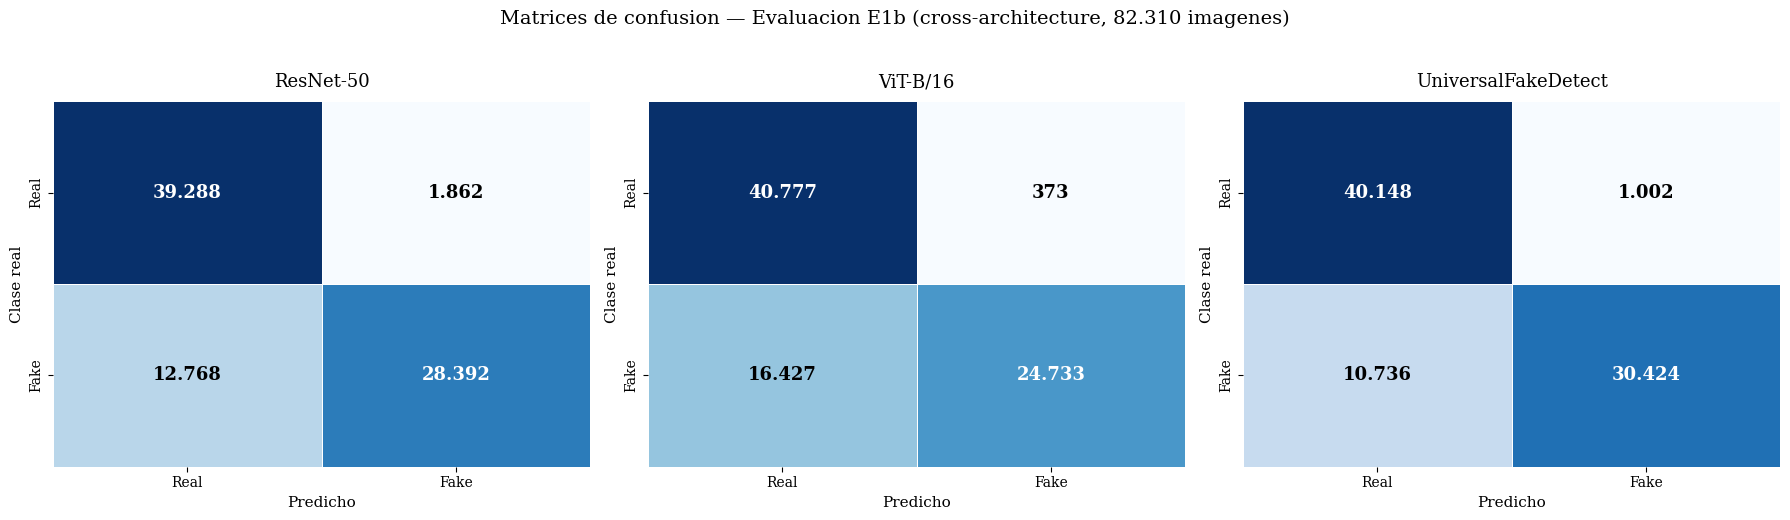

Guardado: /content/drive/MyDrive/tfm-checkpoints/figuras_memoria/matrices_confusion_e1b_comparativa.png


In [ ]:
# Figura 1 — Matrices de confusion E1b comparativa
if not matrices_e1b:
    print('AVISO: confusion_matrix no en metrics.json. Re-evalua con metrics.py actualizado.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    tick_labels = ['Real', 'Fake']

    for ax, modelo in zip(axes, MODELOS):
        cm = np.array(matrices_e1b[modelo])
        cm_norm = cm.astype(float) / cm.max()
        sns.heatmap(cm, annot=False, cmap='Blues',
                    xticklabels=tick_labels, yticklabels=tick_labels,
                    ax=ax, cbar=False, linewidths=0.5, linecolor='white')
        for i in range(2):
            for j in range(2):
                val = cm[i, j]
                val_str = f'{val:,}'.replace(',', '.')
                text_color = 'white' if cm_norm[i, j] > 0.5 else 'black'
                ax.text(j + 0.5, i + 0.5, val_str,
                        ha='center', va='center', fontsize=13, fontweight='bold', color=text_color)
        ax.set_title(modelo, fontsize=13, pad=10)
        ax.set_xlabel('Predicho', fontsize=11)
        ax.set_ylabel('Clase real', fontsize=11)
        ax.tick_params(axis='both', labelsize=10)

    n_total = resultados[MODELOS[0]]['e1b']['n']
    n_str = f'{n_total:,}'.replace(',', '.')
    plt.suptitle(
        f'Matrices de confusion — Evaluacion E1b (cross-architecture, {n_str} imagenes)',
        fontsize=14, y=1.03,
    )
    plt.tight_layout()

    out_path = FIGURAS_DIR / 'matrices_confusion_e1b_comparativa.png'
    plt.savefig(str(out_path), dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {out_path}')


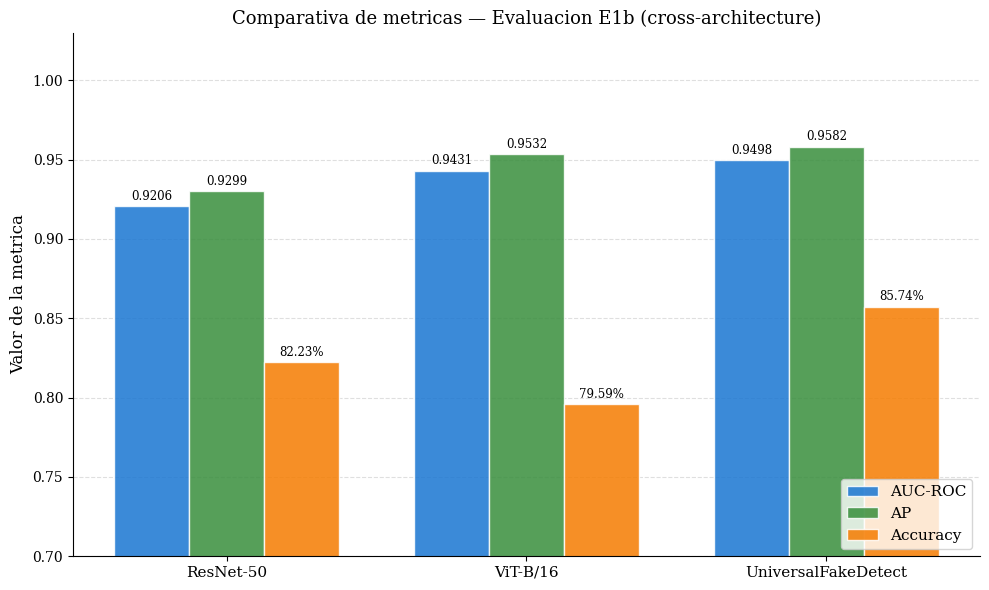

Guardado: /content/drive/MyDrive/tfm-checkpoints/figuras_memoria/barras_metricas_e1b.png


In [ ]:
# Figura 2 — Barras de metricas E1b
fig, ax = plt.subplots(figsize=(10, 6))

metricas_keys   = ['auc',     'ap',     'acc']
metricas_labels = ['AUC-ROC', 'AP',     'Accuracy']
bar_colors      = ['#1976D2', '#388E3C', '#F57C00']
width   = 0.25
x       = np.arange(len(MODELOS))
offsets = [-width, 0.0, width]

for key, label, color, offset in zip(metricas_keys, metricas_labels, bar_colors, offsets):
    valores = [resultados[m]['e1b'][key] for m in MODELOS]
    bars = ax.bar(x + offset, valores, width, label=label, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, valores):
        fmt_str = f'{val * 100:.2f}%' if key == 'acc' else f'{val:.4f}'
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                fmt_str, ha='center', va='bottom', fontsize=8.5)

ax.set_ylim(0.70, 1.03)
ax.set_xticks(x)
ax.set_xticklabels(MODELOS, fontsize=11)
ax.set_ylabel('Valor de la metrica', fontsize=12)
ax.set_title('Comparativa de metricas — Evaluacion E1b (cross-architecture)', fontsize=13)
ax.legend(fontsize=11, loc='lower right')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()

out_path = FIGURAS_DIR / 'barras_metricas_e1b.png'
plt.savefig(str(out_path), dpi=300, bbox_inches='tight')
plt.show()
print(f'Guardado: {out_path}')


  ResNet-50: OK
  ViT-B/16: OK
  UniversalFakeDetect: OK


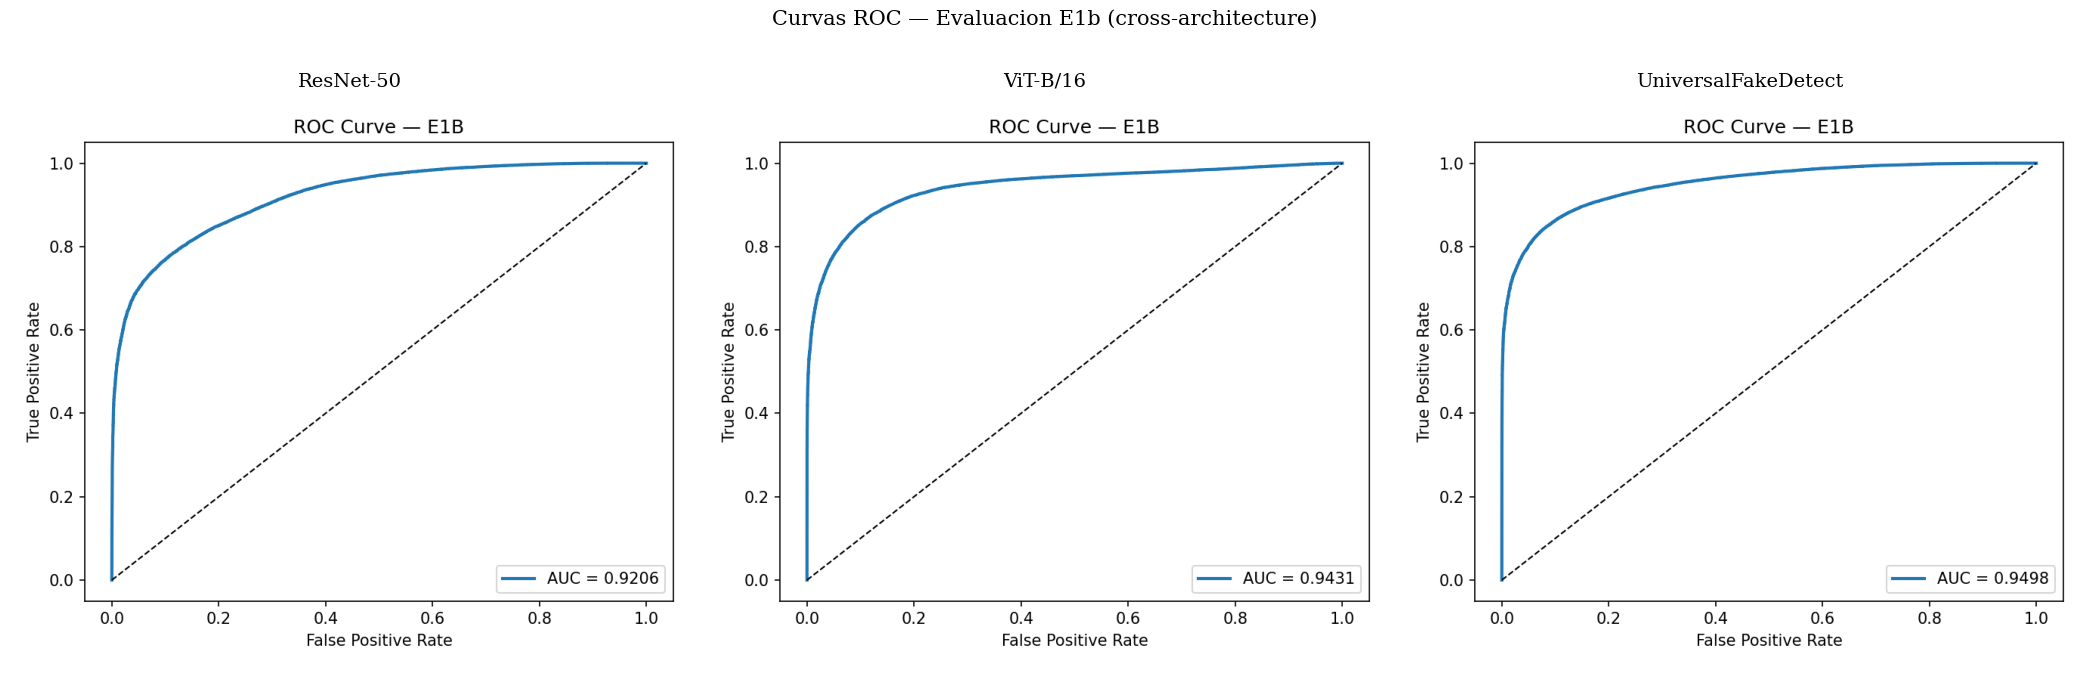

Guardado: /content/drive/MyDrive/tfm-checkpoints/figuras_memoria/roc_curves_e1b_paneles.png


In [ ]:
# Figura 3B — Curvas ROC en paneles (PNGs del evaluador)
roc_pngs = {m: Path(CKPT_BASE) / folder / 'roc_curve_e1b.png'
            for m, folder in modelo_folders.items()}

for modelo, ruta in roc_pngs.items():
    print(f'  {modelo}: {"OK" if ruta.exists() else "NO ENCONTRADO"}')

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
for ax, (modelo, png_path) in zip(axes, roc_pngs.items()):
    img = mpimg.imread(str(png_path))
    ax.imshow(img)
    ax.set_title(modelo, fontsize=14, pad=10)
    ax.axis('off')

plt.suptitle('Curvas ROC — Evaluacion E1b (cross-architecture)', fontsize=15, y=1.01)
plt.tight_layout()

out_path = FIGURAS_DIR / 'roc_curves_e1b_paneles.png'
plt.savefig(str(out_path), dpi=300, bbox_inches='tight')
plt.show()
print(f'Guardado: {out_path}')


In [ ]:
# Inferencia E1b — un pase por modelo (~5 min por modelo en T4)
import sys
sys.path.insert(0, '/content/tfm_deteccion')

import torch
from torch.utils.data import DataLoader
from sklearn.metrics import roc_curve, auc as sklearn_auc
from tqdm import tqdm

import data.cnndetection_dataset
from models import model_registry
from utils.config import load_config
from data.cnndetection_dataset import CNNDetectionDataset
from data.transforms import get_eval_transforms
from evaluation.metrics import compute_metrics

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
E1B_ROOT = '/content/CNN_synth_testset'
print(f'Device: {DEVICE}')

modelos_3a = {
    'ResNet-50': {
        'config':     Path('/content/tfm_deteccion/configs/resnet50.yaml'),
        'checkpoint': Path(CKPT_BASE) / 'resnet50_20260508_115724' / 'checkpoint_best.pth',
        'module':     'models.resnet50',
        'csv_key':    'resnet50',
        'color':      '#1976D2',
    },
    'ViT-B/16': {
        'config':     Path('/content/tfm_deteccion/configs/vit.yaml'),
        'checkpoint': Path(CKPT_BASE) / 'vit_20260509_122527' / 'checkpoint_best.pth',
        'module':     'models.vit',
        'csv_key':    'vit',
        'color':      '#388E3C',
    },
    'UniversalFakeDetect': {
        'config':     Path('/content/tfm_deteccion/configs/universalfakedetect.yaml'),
        'checkpoint': Path(CKPT_BASE) / 'universalfakedetect_20260509_153838' / 'checkpoint_best.pth',
        'module':     'models.universalfakedetect',
        'csv_key':    'ufd',
        'color':      '#F57C00',
    },
}

print('Checkpoints:')
for nombre, info in modelos_3a.items():
    estado = 'OK' if info['checkpoint'].exists() else 'NO ENCONTRADO'
    print(f'  {nombre}: {estado}')
n_arqs = len(list(Path(E1B_ROOT).glob('*_test'))) if Path(E1B_ROOT).exists() else 0
print(f'E1B_ROOT: {E1B_ROOT}  ({n_arqs} arquitecturas GAN)')


Device: cuda
Checkpoints:
  ResNet-50: OK
  ViT-B/16: OK
  UniversalFakeDetect: OK
E1B_ROOT: /content/CNN_synth_testset  (12 arquitecturas GAN)


In [ ]:
desglose_data = {}
roc_data      = {}

for nombre, info in modelos_3a.items():
    csv_key = info['csv_key']
    print('\n' + '='*55)
    print(f'  Modelo: {nombre}')
    print('='*55)

    cfg = load_config(info['config'])
    importlib.import_module(info['module'])
    model = model_registry.build(cfg.model.name, **vars(cfg.model.kwargs))
    ckpt = torch.load(str(info['checkpoint']), map_location='cpu')
    model.load_state_dict(ckpt['model_state_dict'])
    model.to(DEVICE).eval()
    best_auc = ckpt.get('best_auc', float('nan'))
    print(f'  Checkpoint cargado (val best_auc={best_auc:.4f})')

    dataset = CNNDetectionDataset(root=E1B_ROOT, split='test', transform=get_eval_transforms())
    loader  = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
    print(f'  Dataset E1b: {len(dataset)} imagenes')

    all_scores, all_targets, all_generators = [], [], []
    with torch.no_grad():
        for images, labels, generators in tqdm(loader, desc='  Inferencia'):
            images = model.preprocess(images.to(DEVICE))
            logits = model(images).squeeze(1)
            scores = torch.sigmoid(logits).cpu().numpy()
            all_scores.extend(scores.tolist())
            all_targets.extend(labels.numpy().tolist())
            all_generators.extend(generators)

    y_true  = np.array(all_targets)
    y_score = np.array(all_scores)
    gens    = np.array(all_generators)

    pt_path = FIGURAS_DIR / f'{csv_key}_e1b_predictions.pt'
    torch.save({'y_true':  torch.tensor(y_true,  dtype=torch.float32),
                'y_score': torch.tensor(y_score, dtype=torch.float32),
                'generators': list(gens)}, str(pt_path))
    print(f'  Predictions guardadas: {pt_path}')

    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_global  = sklearn_auc(fpr, tpr)
    roc_data[nombre] = {'fpr': fpr, 'tpr': tpr, 'auc': auc_global, 'color': info['color']}
    print(f'  AUC-ROC global E1b: {auc_global:.4f}')

    arqs = sorted(set(gens))
    print(f'  Arquitecturas ({len(arqs)}): {", ".join(arqs)}')
    print('  ' + '-'*55)
    for arch in arqs:
        mask = gens == arch
        m = compute_metrics(y_true[mask], y_score[mask])
        if arch not in desglose_data:
            desglose_data[arch] = {'n_samples': int(mask.sum())}
        desglose_data[arch][f'{csv_key}_auc'] = m['auc_roc']
        desglose_data[arch][f'{csv_key}_ap']  = m['average_precision']
        desglose_data[arch][f'{csv_key}_acc'] = m['accuracy']
        auc_v = m['auc_roc']
        ap_v  = m['average_precision']
        acc_v = m['accuracy']
        print(f'  {arch:25s}  AUC={auc_v:.4f}  AP={ap_v:.4f}  Acc={acc_v:.4f}')

    del model
    torch.cuda.empty_cache()

print(f'\nInferencia completada: {list(roc_data.keys())}')



  Modelo: ResNet-50
  Checkpoint cargado (val best_auc=1.0000)
  Dataset E1b: 82310 imagenes


  Inferencia: 100%|██████████| 1287/1287 [07:11<00:00,  2.98it/s]


  Predictions guardadas: /content/drive/MyDrive/tfm-checkpoints/figuras_memoria/resnet50_e1b_predictions.pt
  AUC-ROC global E1b: 0.9206
  Arquitecturas (12): biggan, crn, cyclegan, deepfake, gaugan, imle, san, seeingdark, stargan, stylegan, stylegan2, whichfaceisreal
  -------------------------------------------------------
  biggan                     AUC=0.9154  AP=0.8980  Acc=0.7430
  crn                        AUC=0.9925  AP=0.9908  Acc=0.9479
  cyclegan                   AUC=0.9735  AP=0.9712  Acc=0.9167
  deepfake                   AUC=0.8463  AP=0.8449  Acc=0.5123
  gaugan                     AUC=0.9311  AP=0.9175  Acc=0.7923
  imle                       AUC=0.9984  AP=0.9981  Acc=0.9507
  san                        AUC=0.5374  AP=0.5798  Acc=0.5155
  seeingdark                 AUC=0.8461  AP=0.8234  Acc=0.7000
  stargan                    AUC=1.0000  AP=1.0000  Acc=0.9902
  stylegan                   AUC=0.9560  AP=0.9644  Acc=0.7986
  stylegan2                  AUC=0.9905  AP

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Checkpoint cargado (val best_auc=1.0000)
  Dataset E1b: 82310 imagenes


  Inferencia: 100%|██████████| 1287/1287 [32:51<00:00,  1.53s/it]


  Predictions guardadas: /content/drive/MyDrive/tfm-checkpoints/figuras_memoria/ufd_e1b_predictions.pt
  AUC-ROC global E1b: 0.9498
  Arquitecturas (12): biggan, crn, cyclegan, deepfake, gaugan, imle, san, seeingdark, stargan, stylegan, stylegan2, whichfaceisreal
  -------------------------------------------------------
  biggan                     AUC=0.9878  AP=0.9895  Acc=0.9423
  crn                        AUC=0.9775  AP=0.9776  Acc=0.9014
  cyclegan                   AUC=0.9964  AP=0.9968  Acc=0.9542
  deepfake                   AUC=0.8973  AP=0.9154  Acc=0.6305
  gaugan                     AUC=0.9998  AP=0.9998  Acc=0.9795
  imle                       AUC=0.9983  AP=0.9982  Acc=0.9798
  san                        AUC=0.5877  AP=0.6262  Acc=0.5322
  seeingdark                 AUC=0.7845  AP=0.8244  Acc=0.7278
  stargan                    AUC=0.9974  AP=0.9976  Acc=0.9837
  stylegan                   AUC=0.9738  AP=0.9738  Acc=0.8237
  stylegan2                  AUC=0.9636  AP=0.96

In [ ]:
CSV_COLS = [
    'arquitectura_gan', 'n_samples',
    'resnet50_auc', 'resnet50_ap', 'resnet50_acc',
    'vit_auc',      'vit_ap',      'vit_acc',
    'ufd_auc',      'ufd_ap',      'ufd_acc',
]

csv_path = FIGURAS_DIR / 'desglose_e1b_por_arquitectura.csv'
with csv_path.open('w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=CSV_COLS, extrasaction='ignore')
    writer.writeheader()
    for arch in sorted(desglose_data.keys()):
        row = {'arquitectura_gan': arch, **desglose_data[arch]}
        writer.writerow(row)

print(f'CSV guardado: {csv_path}\n')
print('Arquitectura GAN           N      ResNet AUC   ViT AUC   UFD AUC')
print('-' * 65)
for arch in sorted(desglose_data.keys(), key=lambda a: -desglose_data[a].get('resnet50_auc', 0)):
    d = desglose_data[arch]
    n     = d['n_samples']
    r_auc = d.get('resnet50_auc', float('nan'))
    v_auc = d.get('vit_auc',      float('nan'))
    u_auc = d.get('ufd_auc',      float('nan'))
    print(f'{arch:25s}  {n:>6}  {r_auc:>10.4f}  {v_auc:>9.4f}  {u_auc:>9.4f}')


CSV guardado: /content/drive/MyDrive/tfm-checkpoints/figuras_memoria/desglose_e1b_por_arquitectura.csv

Arquitectura GAN           N      ResNet AUC   ViT AUC   UFD AUC
-----------------------------------------------------------------
stargan                      3998      1.0000     0.9972     0.9974
imle                        12764      0.9984     0.9976     0.9983
crn                         12764      0.9925     0.9835     0.9775
stylegan2                   15976      0.9905     0.9824     0.9636
cyclegan                     2642      0.9735     0.9885     0.9964
stylegan                    11982      0.9560     0.9295     0.9738
gaugan                      10000      0.9311     0.9621     0.9998
biggan                       4000      0.9154     0.9326     0.9878
whichfaceisreal              2000      0.8770     0.9171     0.9749
deepfake                     5405      0.8463     0.6980     0.8973
seeingdark                    360      0.8461     0.9165     0.7845
san              

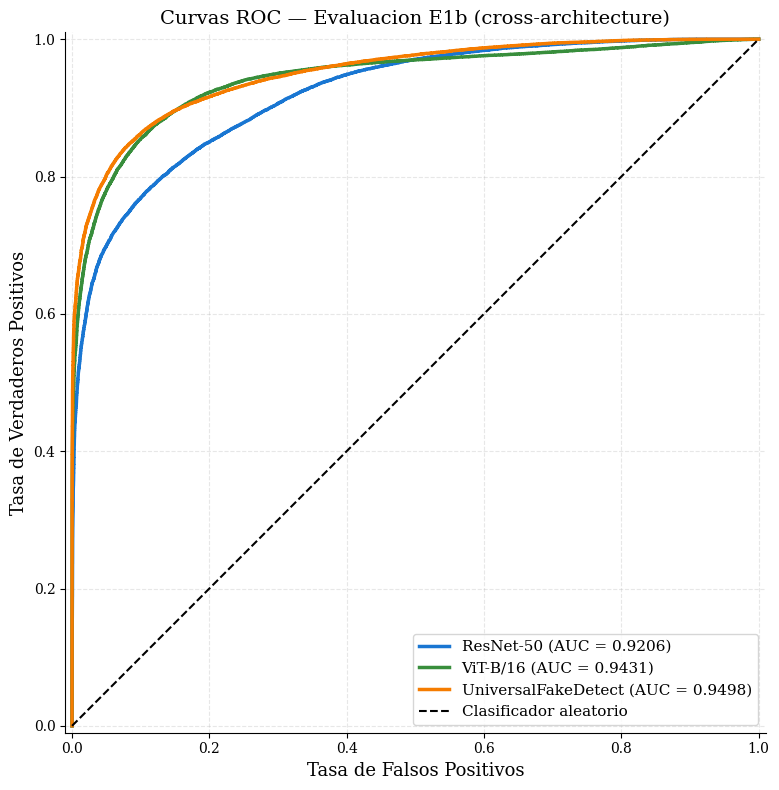

Guardado: /content/drive/MyDrive/tfm-checkpoints/figuras_memoria/roc_curves_e1b_superpuestas.png


In [ ]:
# Figura 3A — Curvas ROC E1b superpuestas
fig, ax = plt.subplots(figsize=(8, 8))
for nombre, rd in roc_data.items():
    rd_auc = rd['auc']
    ax.plot(rd['fpr'], rd['tpr'], color=rd['color'], lw=2.5,
            label=f'{nombre} (AUC = {rd_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=13)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=13)
ax.set_title('Curvas ROC — Evaluacion E1b (cross-architecture)', fontsize=14)
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

out_path = FIGURAS_DIR / 'roc_curves_e1b_superpuestas.png'
plt.savefig(str(out_path), dpi=300, bbox_inches='tight')
plt.show()
print(f'Guardado: {out_path}')


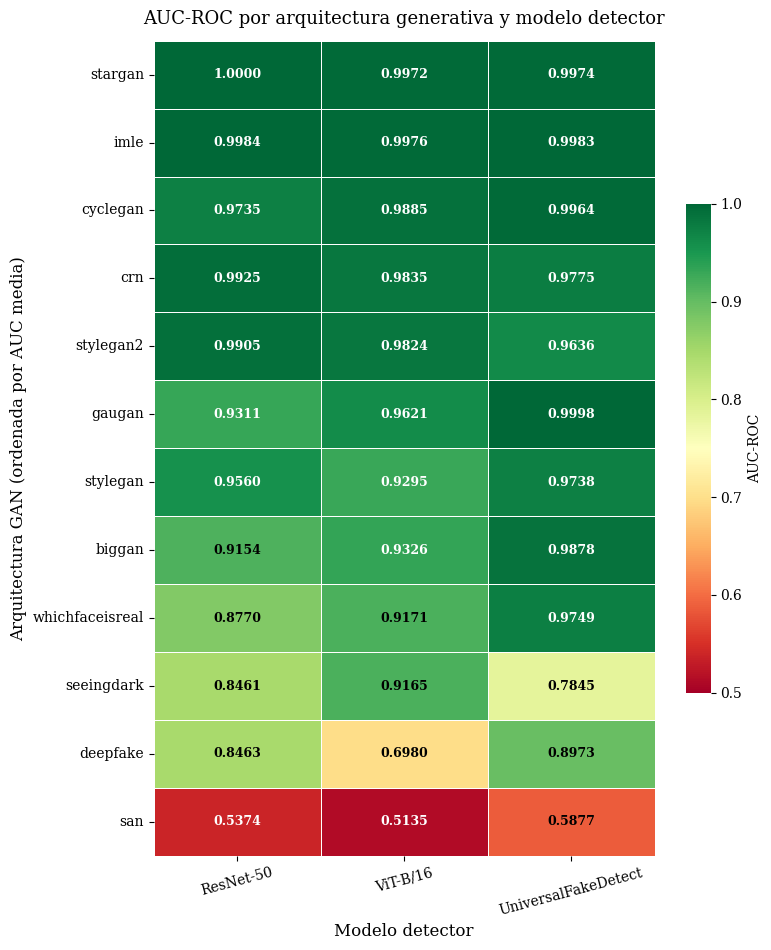

Guardado: /content/drive/MyDrive/tfm-checkpoints/figuras_memoria/heatmap_auc_por_generador.png

Figuras en /content/drive/MyDrive/tfm-checkpoints/figuras_memoria:
  barras_metricas_e1b.png                                    168.8 KB
  desglose_e1b_por_arquitectura.csv                            2.1 KB
  heatmap_auc_por_generador.png                              365.5 KB
  matrices_confusion_e1b_comparativa.png                     180.1 KB
  resnet50_e1b_predictions.pt                               9911.0 KB
  roc_curves_e1b_paneles.png                                 468.8 KB
  roc_curves_e1b_superpuestas.png                            262.5 KB
  ufd_e1b_predictions.pt                                    9910.9 KB
  vit_e1b_predictions.pt                                    9910.9 KB


In [ ]:
# Heatmap AUC-ROC por arquitectura GAN x modelo detector + resumen de archivos
csvkeys_hm  = ['resnet50_auc', 'vit_auc', 'ufd_auc']
arqs_sorted = sorted(
    desglose_data.keys(),
    key=lambda a: -np.mean([desglose_data[a].get(k, 0.0) for k in csvkeys_hm]),
)

heat_matrix = np.array([
    [desglose_data[arch].get(k, np.nan) for k in csvkeys_hm]
    for arch in arqs_sorted
])

fig, ax = plt.subplots(figsize=(8, max(4, len(arqs_sorted) * 0.8)))
sns.heatmap(
    heat_matrix, annot=False, cmap='RdYlGn', vmin=0.5, vmax=1.0,
    xticklabels=MODELOS, yticklabels=arqs_sorted,
    ax=ax, linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'AUC-ROC', 'shrink': 0.6},
)

for i, arch in enumerate(arqs_sorted):
    for jj, key in enumerate(csvkeys_hm):
        val = desglose_data[arch].get(key, np.nan)
        if not np.isnan(val):
            norm = (val - 0.5) / 0.5
            text_color = 'white' if norm < 0.15 or norm > 0.85 else 'black'
            ax.text(jj + 0.5, i + 0.5, f'{val:.4f}',
                    ha='center', va='center', fontsize=9, fontweight='bold', color=text_color)

ax.set_title('AUC-ROC por arquitectura generativa y modelo detector', fontsize=13, pad=12)
ax.set_xlabel('Modelo detector', fontsize=12)
ax.set_ylabel('Arquitectura GAN (ordenada por AUC media)', fontsize=12)
ax.tick_params(axis='x', rotation=15, labelsize=10)
ax.tick_params(axis='y', rotation=0,  labelsize=10)
plt.tight_layout()

out_path = FIGURAS_DIR / 'heatmap_auc_por_generador.png'
plt.savefig(str(out_path), dpi=300, bbox_inches='tight')
plt.show()
print(f'Guardado: {out_path}')

print(f'\nFiguras en {FIGURAS_DIR}:')
for archivo in sorted(FIGURAS_DIR.iterdir()):
    size_kb = archivo.stat().st_size / 1024
    print(f'  {archivo.name:55s}  {size_kb:>7.1f} KB')
